# What Does Our Sales Data Actually Look Like?

**Business Question:** Before making any decisions about pricing, staffing, or promotions — 
do we actually understand our data?

**The Insight Most People Skip:** Everyone jumps to "what predicts sales?" 
But if you don't understand the *shape* of your data first, every analysis after this is built on sand.

**Dataset:** Restaurant tips data (244 transactions)  
**Tools:** pandas, seaborn, matplotlib  
**Key Skill:** Exploratory Data Analysis (EDA), Distributions

## Step 1: Load and Preview the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean, professional style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Load the tips dataset
tips = sns.load_dataset('tips')
print(f"Dataset: {tips.shape[0]} transactions, {tips.shape[1]} columns\n")
tips.head(10)

Dataset: 244 transactions, 7 columns



,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


## Step 2: What Types of Data Do We Have?

In [2]:
print("Column Types:\n")
for col in tips.columns:
    dtype = tips[col].dtype
    n_unique = tips[col].nunique()
    example = tips[col].iloc[0]
    print(f"  {col:12s} | {str(dtype):10s} | {n_unique:3d} unique | e.g., {example}")

print(f"\n{'='*60}")
print(f"\nCategorical columns: {list(tips.select_dtypes(include='category').columns)}")
print(f"Numerical columns:  {list(tips.select_dtypes(include='number').columns)}")

Column Types:

  total_bill   | float64    | 229 unique | e.g., 16.99
  tip          | float64    | 123 unique | e.g., 1.01
  sex          | category   |   2 unique | e.g., Female
  smoker       | category   |   2 unique | e.g., No
  day          | category   |   4 unique | e.g., Sun
  time         | category   |   2 unique | e.g., Dinner
  size         | int64      |   6 unique | e.g., 2


Categorical columns: ['sex', 'smoker', 'day', 'time']
Numerical columns:  ['total_bill', 'tip', 'size']


## Step 3: The Shape of Our Data — Distributions

This is where most people skip ahead. But the **distribution** of your data tells you:
- Are there outliers that will mess up your averages?
- Is the data symmetric or skewed?
- Where do most values cluster?

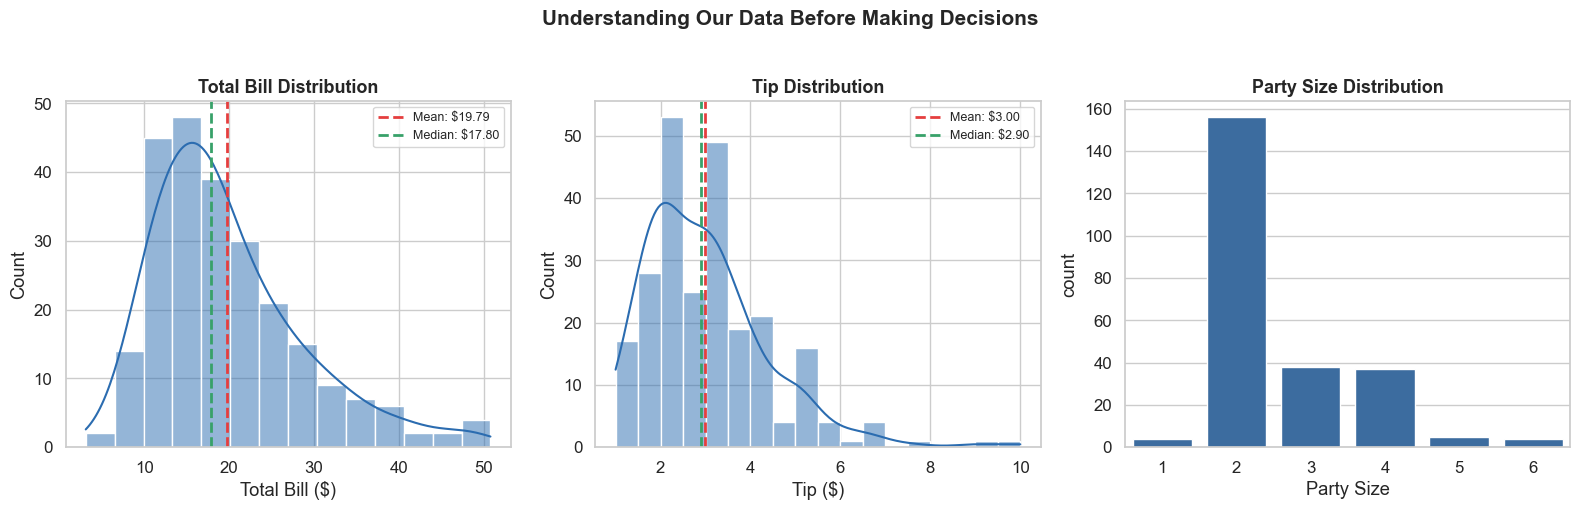

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total bill distribution
sns.histplot(tips['total_bill'], kde=True, ax=axes[0], color='#2B6CB0', edgecolor='white')
axes[0].axvline(tips['total_bill'].mean(), color='#E53E3E', linestyle='--', linewidth=2, label=f"Mean: ${tips['total_bill'].mean():.2f}")
axes[0].axvline(tips['total_bill'].median(), color='#38A169', linestyle='--', linewidth=2, label=f"Median: ${tips['total_bill'].median():.2f}")
axes[0].set_title('Total Bill Distribution', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Total Bill ($)')
axes[0].legend(fontsize=9)

# Tip distribution
sns.histplot(tips['tip'], kde=True, ax=axes[1], color='#2B6CB0', edgecolor='white')
axes[1].axvline(tips['tip'].mean(), color='#E53E3E', linestyle='--', linewidth=2, label=f"Mean: ${tips['tip'].mean():.2f}")
axes[1].axvline(tips['tip'].median(), color='#38A169', linestyle='--', linewidth=2, label=f"Median: ${tips['tip'].median():.2f}")
axes[1].set_title('Tip Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Tip ($)')
axes[1].legend(fontsize=9)

# Party size distribution
sns.countplot(x='size', data=tips, ax=axes[2], color='#2B6CB0', edgecolor='white')
axes[2].set_title('Party Size Distribution', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Party Size')

plt.suptitle('Understanding Our Data Before Making Decisions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

### What This Tells Us

1. **Total bill is right-skewed** — most bills are $10–$25, but some go up to $50+. 
   The mean ($19.79) is pulled higher than the median ($17.80). 
   **If someone asks "what's the typical bill?" — the median is more honest.**

2. **Tips are also right-skewed** — most tips are $2–$4, with occasional big tippers.

3. **Most tables are 2 people** — this is overwhelmingly a couples/date restaurant.

## Step 4: Categorical Breakdown — Where Does the Business Come From?

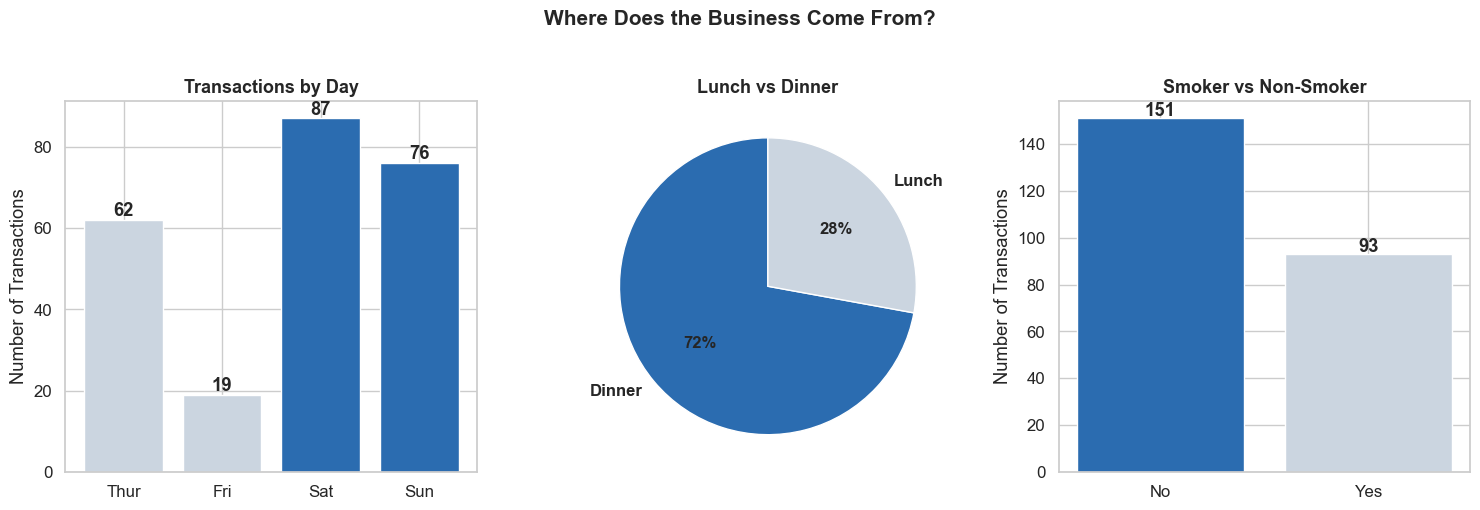

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Day distribution
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
day_counts = tips['day'].value_counts().reindex(day_order)
bars = axes[0].bar(day_counts.index, day_counts.values, color=['#CBD5E0', '#CBD5E0', '#2B6CB0', '#2B6CB0'], edgecolor='white')
axes[0].set_title('Transactions by Day', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
for bar, val in zip(bars, day_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontweight='bold')

# Time distribution
time_counts = tips['time'].value_counts()
colors = ['#2B6CB0', '#CBD5E0']
axes[1].pie(time_counts.values, labels=time_counts.index, autopct='%1.0f%%', colors=colors,
            textprops={'fontsize': 12, 'fontweight': 'bold'}, startangle=90)
axes[1].set_title('Lunch vs Dinner', fontweight='bold', fontsize=13)

# Smoker distribution
smoker_counts = tips['smoker'].value_counts()
axes[2].bar(smoker_counts.index, smoker_counts.values, color=['#2B6CB0', '#CBD5E0'], edgecolor='white')
axes[2].set_title('Smoker vs Non-Smoker', fontweight='bold', fontsize=13)
axes[2].set_ylabel('Number of Transactions')
for i, (idx, val) in enumerate(smoker_counts.items()):
    axes[2].text(i, val + 1, str(val), ha='center', fontweight='bold')

plt.suptitle('Where Does the Business Come From?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_categorical.png', bbox_inches='tight', dpi=150)
plt.show()

### Business Insights

- **Weekend dominates:** Saturday and Sunday account for 65% of transactions
- **Dinner is the main meal:** 72% of transactions happen at dinner
- **Non-smokers are the majority:** 62% of customers don't smoke

## Step 5: Quick Summary Statistics

In [5]:
summary = tips[['total_bill', 'tip', 'size']].describe().round(2)
print("Summary Statistics")
print("=" * 50)
print(summary)

print(f"\n{'='*50}")
print(f"\nTip as % of bill:")
tips['tip_pct'] = (tips['tip'] / tips['total_bill'] * 100).round(1)
print(f"  Mean tip %:   {tips['tip_pct'].mean():.1f}%")
print(f"  Median tip %: {tips['tip_pct'].median():.1f}%")
print(f"  Std dev:      {tips['tip_pct'].std():.1f}%")

Summary Statistics
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


Tip as % of bill:
  Mean tip %:   16.1%
  Median tip %: 15.4%
  Std dev:      6.1%


## Key Finding

> ** Most customers tip around 15-17% of their bill, but the distribution is right-skewed — 
> a few generous tippers pull the average up. If you're benchmarking "normal," use the median (15.5%), not the mean (16.1%).**

This is exactly why understanding distributions matters *before* you analyze anything else.

## LinkedIn Post Draft

```
Before analyzing data, you need to understand its shape.

I explored 244 restaurant transactions and found:

• Most bills cluster at $10–$25 (right-skewed)
• The "average" tip % is misleading — median (15.5%) is more honest than mean (16.1%)
• 65% of business happens on weekends
• 72% of revenue comes from dinner

 If you don't understand your distribution first, every analysis after is built on sand.

Full notebook with code: [GitHub link]

#DataAnalytics #Statistics #Python #EDA
```

---

**Next notebook:** [Analyzing customer spending patterns →](02-customer-spending-patterns.ipynb)